In [1]:
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import pandas as pd

In [11]:
maxi = pd.read_csv('hr_rr_t_ag_dbp_sbp_age_gender_mortality_elixhauser_hem_urea_urine_rdw_htc.csv')

In [12]:
abdul_karim = pd.read_csv('final_data_table_karim.csv')

In [13]:
abdul_karim

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,DIAGNOSIS,GCS_max,GCS_mean,Lactate_min,Lactate_max,Lactate_mean,BUN_min,BUN_mean,AG_max,AG_mean,Bilirubin_max,Bilirubin_mean,MORTALITY_INHOSPITAL
0,3,145834,211552,HYPOTENSION,6.0,4.444444,1.3,8.8,3.800000,36.0,40.500000,23.0,18.400000,0.8,0.800000,0
1,6,107064,228232,CHRONIC RENAL FAILURE/SDA,6.0,6.000000,NaN,NaN,NaN,65.0,65.500000,20.0,19.000000,0.2,0.200000,0
2,9,150750,220597,HEMORRHAGIC CVA,5.0,2.600000,1.9,2.7,2.380000,17.0,18.500000,13.0,12.500000,0.4,0.400000,1
3,12,112213,232669,PANCREATIC CANCER/SDA,6.0,4.842105,1.6,15.1,8.716667,28.0,35.500000,28.0,14.750000,9.9,9.050000,1
4,17,194023,277042,PATIENT FORAMEN OVALE\ PATENT FORAMEN OVALE MI...,6.0,5.615385,0.9,0.9,0.900000,10.0,10.666667,12.0,11.500000,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22360,99982,151454,221194,TVR,5.0,3.666667,1.5,2.5,1.925000,21.0,25.000000,15.0,13.000000,1.4,1.400000,0
22361,99982,183791,239827,BIVENTRICULAR HEART FAILURE,5.0,5.000000,NaN,NaN,NaN,32.0,35.833333,14.0,10.166667,NaN,NaN,0
22362,99985,176670,279638,FEVER,5.0,1.615385,1.2,2.1,1.650000,13.0,15.333333,13.0,12.000000,1.1,0.866667,0
22363,99991,151118,226241,DIVERTICULITIS/SDA,5.0,5.000000,1.0,1.1,1.050000,17.0,19.000000,12.0,11.500000,NaN,NaN,0


In [14]:
columns_to_keep = [
    'ICUSTAY_ID',
    'AG_MEAN', 'AG_MAX', 'AG_MEDIAN', 'AG_MIN', 'AG_STD',
    'SYSBP_MIN', 'SYSBP_MEAN', 'SYSBP_STD',
    'DIASBP_MIN', 'DIASBP_MEAN',
    'AGE',
    'RR_MEAN', 'RR_STD', 'RR_MAX', 'RR_MIN',
    'TEMP_STD', 'TEMP_MIN',
    'HR_MEAN', 'HR_MAX', 'HR_STD',
    'RDW_max', 'RDW_mean', 'RDW_min', 'RDW_std',
    'age_adj_comorbidity_score'
]

maxi = maxi[columns_to_keep]

In [15]:
maxi

,ICUSTAY_ID,AG_MEAN,AG_MAX,AG_MEDIAN,AG_MIN,AG_STD,SYSBP_MIN,SYSBP_MEAN,SYSBP_STD,DIASBP_MIN,...,TEMP_STD,TEMP_MIN,HR_MEAN,HR_MAX,HR_STD,RDW_max,RDW_mean,RDW_min,RDW_std,age_adj_comorbidity_score
0,280836,13.900000,15.0,14.5,12.0,1.370320,15.0,106.836735,27.048903,12.0,...,0.789344,37.111113,103.101695,190.0,25.040447,13.1,12.925000,12.7,0.206155,22.0
1,206613,11.000000,15.0,10.5,9.0,2.280351,83.0,101.569231,9.154864,32.0,...,0.790769,37.277777,117.653846,147.0,15.438537,12.8,12.675000,12.5,0.150000,4.0
2,220345,15.500000,18.0,16.0,12.0,2.516611,71.0,122.848101,17.451830,33.0,...,0.192450,36.222221,56.875000,70.0,6.499084,14.4,14.166667,14.0,0.208167,19.0
3,254851,13.250000,14.0,13.5,12.0,0.957427,88.0,151.995851,17.360515,44.0,...,0.742393,35.611110,92.716981,116.0,11.774120,13.7,12.966667,12.6,0.635085,2.0
4,219649,14.500000,22.0,13.0,11.0,4.037326,90.0,139.056995,18.354775,50.0,...,0.544847,35.833333,59.933333,90.0,8.632391,14.3,14.200000,14.1,0.141421,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21173,270429,11.833333,14.0,12.0,9.0,1.834848,65.0,109.971429,15.424403,33.0,...,0.730357,37.055556,111.625000,134.0,11.510633,16.6,16.116667,15.8,0.299444,14.0
21174,201233,9.714286,12.0,9.0,7.0,1.799471,70.0,128.093333,22.882882,39.0,...,1.020552,35.055556,87.218182,106.0,8.285844,12.8,12.725000,12.7,0.050000,8.0
21175,283653,8.000000,10.0,8.0,6.0,1.581139,118.0,149.054545,17.266343,24.0,...,0.600147,35.777778,72.720000,94.0,13.516490,15.2,15.200000,15.2,0.000000,11.0
21176,202802,12.000000,12.0,12.0,12.0,NaN,72.0,108.389610,12.071231,29.0,...,0.908366,35.700000,99.000000,144.0,14.645819,18.3,17.800000,17.2,0.556776,2.0


In [16]:
abdul_karim['ICUSTAY_ID'].nunique()

22365

In [17]:
abdul_karim.columns

Index(['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'DIAGNOSIS', 'GCS_max',
       'GCS_mean', 'Lactate_min', 'Lactate_max', 'Lactate_mean', 'BUN_min',
       'BUN_mean', 'AG_max', 'AG_mean', 'Bilirubin_max', 'Bilirubin_mean',
       'MORTALITY_INHOSPITAL'],
      dtype='object')

In [18]:
columns_to_keep = ['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'DIAGNOSIS', 'GCS_max',
       'GCS_mean', 'Lactate_min', 'Lactate_max', 'Lactate_mean', 'BUN_min',
       'BUN_mean', 'Bilirubin_max', 'Bilirubin_mean',
       'MORTALITY_INHOSPITAL']

abdul_karim = abdul_karim[columns_to_keep]

In [19]:
maxi['ICUSTAY_ID'].nunique()

21178

In [20]:
abdul_karim_maxi_df = pd.merge(abdul_karim, maxi, on='ICUSTAY_ID', how='inner')

In [21]:
abdul_karim_maxi_df['ICUSTAY_ID'].nunique()

21178

In [22]:
abdul_karim_maxi_df.columns

Index(['SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'DIAGNOSIS', 'GCS_max',
       'GCS_mean', 'Lactate_min', 'Lactate_max', 'Lactate_mean', 'BUN_min',
       'BUN_mean', 'Bilirubin_max', 'Bilirubin_mean', 'MORTALITY_INHOSPITAL',
       'AG_MEAN', 'AG_MAX', 'AG_MEDIAN', 'AG_MIN', 'AG_STD', 'SYSBP_MIN',
       'SYSBP_MEAN', 'SYSBP_STD', 'DIASBP_MIN', 'DIASBP_MEAN', 'AGE',
       'RR_MEAN', 'RR_STD', 'RR_MAX', 'RR_MIN', 'TEMP_STD', 'TEMP_MIN',
       'HR_MEAN', 'HR_MAX', 'HR_STD', 'RDW_max', 'RDW_mean', 'RDW_min',
       'RDW_std', 'age_adj_comorbidity_score'],
      dtype='object')

In [23]:
abdul_karim_maxi_df = abdul_karim_maxi_df.drop('DIAGNOSIS', axis=1)

In [24]:
abdul_karim_maxi_df.to_csv('third_feature_df_28_12_2025.csv', index = False)

In [25]:
x = pd.read_csv('third_feature_df_28_12_2025.csv')

x.head(5)

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,GCS_max,GCS_mean,Lactate_min,Lactate_max,Lactate_mean,BUN_min,BUN_mean,...,TEMP_STD,TEMP_MIN,HR_MEAN,HR_MAX,HR_STD,RDW_max,RDW_mean,RDW_min,RDW_std,age_adj_comorbidity_score
0,3,145834,211552,6.0,4.444444,1.3,8.8,3.800000,36.0,40.500000,...,0.335085,36.200001,98.925373,168.0,28.103334,15.7,15.400000,15.0,0.273861,16.0
1,6,107064,228232,6.0,6.000000,NaN,NaN,NaN,65.0,65.500000,...,0.441010,36.000002,84.791667,100.0,5.573334,17.0,16.450000,15.9,0.777817,12.0
2,9,150750,220597,5.0,2.600000,1.9,2.7,2.380000,17.0,18.500000,...,0.822093,35.500001,87.644737,111.0,8.162849,14.3,14.000000,13.8,0.264575,12.0
3,12,112213,232669,6.0,4.842105,1.6,15.1,8.716667,28.0,35.500000,...,0.837151,35.500001,83.208333,105.0,8.518311,14.9,14.625000,14.2,0.309570,7.0
4,17,194023,277042,6.0,5.615385,0.9,0.9,0.900000,10.0,10.666667,...,0.623295,36.000002,82.400000,114.0,11.049719,12.9,12.766667,12.6,0.152753,0.0


In [27]:
x = pd.read_csv('first_feature_df_17_12_2025.csv')

In [28]:
expected_features = [
    "GCS_max", "GCS_mean", "Lactate_min", "Lactate_max", "Lactate_mean",
    "BUN_min", "BUN_mean", "AG_max", "AG_mean", "Bilirubin_max", "Bilirubin_mean",
    "AG_MEAN", "AG_MAX", "AG_MEDIAN", "AG_MIN", "AG_STD",
    "SYSBP_MIN", "SYSBP_MEAN", "SYSBP_STD",
    "DIASBP_MIN", "DIASBP_MEAN",
    "AGE",
    "RR_MEAN", "RR_STD", "RR_MAX",
    "TEMP_STD", "TEMP_MIN",
    "HR_MEAN", "HR_MAX",
    "age_adj_comorbidity_score",
]

for col in expected_features:
    print(f"{col}: [{x[col].min()}, {x[col].max()}]")

GCS_max: [1.0, 6.0]
GCS_mean: [1.0, 6.0]
Lactate_min: [0.0, 21.2]
Lactate_max: [0.3, 32.0]
Lactate_mean: [0.3, 24.916666666666668]
BUN_min: [0.0, 196.0]
BUN_mean: [1.2857142857142858, 216.5]
AG_max: [5.0, 58.0]
AG_mean: [5.0, 46.875]
Bilirubin_max: [0.0, 79.0]
Bilirubin_mean: [0.0, 68.66666666666667]
AG_MEAN: [5.5, 43.0]
AG_MAX: [6.0, 50.0]
AG_MEDIAN: [5.5, 44.5]
AG_MIN: [5.0, 35.0]
AG_STD: [0.0, 17.03917055884274]
SYSBP_MIN: [0.0599999986588954, 154.0]
SYSBP_MEAN: [29.166666666666668, 185.47115384615384]
SYSBP_STD: [3.51281500808764, 51.85476512979947]
DIASBP_MIN: [0.3199999928474426, 84.0]
DIASBP_MEAN: [14.5, 109.92682926829268]
AGE: [18, 90]
RR_MEAN: [8.325581395348838, 42.80952380952381]
RR_STD: [0.0, 13.758321004205568]
RR_MAX: [12.0, 59.0]
TEMP_STD: [0.0, 2.9912423613270653]
TEMP_MIN: [25.200000762939453, 40.1]
HR_MEAN: [35.93617021276596, 154.44897959183675]
HR_MAX: [53.0, 245.0]
age_adj_comorbidity_score: [0.0, 58.0]


Correlation with MORTALITY_INHOSPITAL:
 MORTALITY_INHOSPITAL         1.000000
Lactate_mean                 0.242353
AG_mean                      0.237943
Lactate_max                  0.229592
AG_max                       0.227699
age_adj_comorbidity_score    0.214751
Lactate_min                  0.206977
AG_MEAN                      0.204531
AG_MEDIAN                    0.203589
BUN_min                      0.202662
BUN_mean                     0.198878
Bilirubin_mean               0.189847
Bilirubin_max                0.189209
AG_MAX                       0.180133
SYSBP_STD                    0.169159
AG_MIN                       0.157463
RR_MEAN                      0.142402
TEMP_STD                     0.127002
HR_MAX                       0.115573
AGE                          0.114018
RR_MAX                       0.098224
HR_MEAN                      0.091811
AG_STD                       0.053301
RR_STD                       0.045124
TEMP_MIN                    -0.106727
DIASBP_MEA

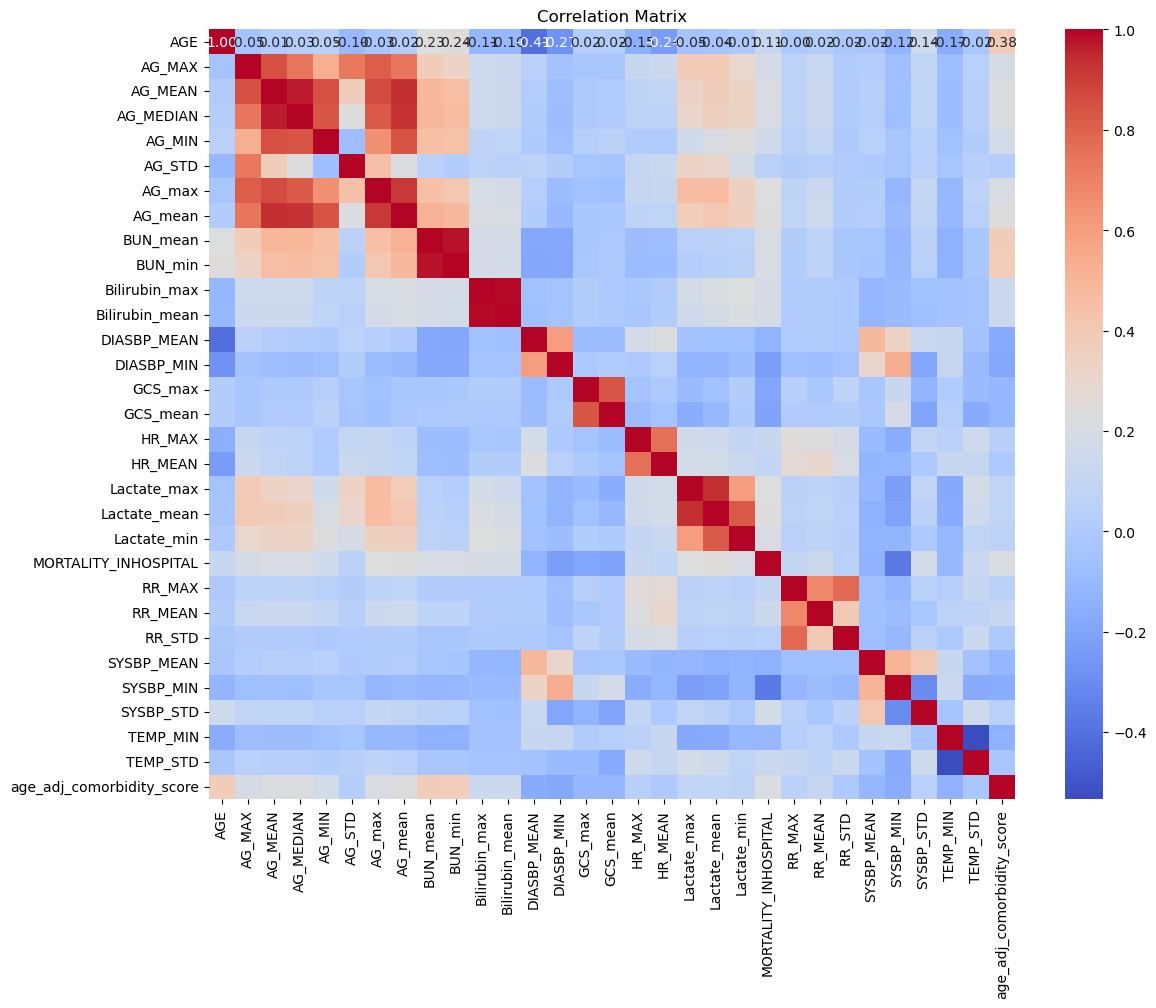

In [29]:
df_corr = x.copy()

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()

# Exclude columns
id_cols = ['SUBJECT_ID', 'ICUSTAY_ID', 'HADM_ID', 'HR_COUNT', 'SYSBP_COUNT', 'DIASBP_COUNT', 'TEMP_COUNT', 'AG_COUNT', 'RR_COUNT', 'HEM_COUNT', 'UREA_COUNT', 'RDW_count']
numeric_cols = [col for col in numeric_cols if col not in id_cols]

# Sort alphabetically
numeric_cols = sorted(numeric_cols)

df_numeric = df_corr[numeric_cols]
corr_matrix = df_numeric.corr()

# Show correlation of features with target
target_corr = corr_matrix['MORTALITY_INHOSPITAL'].sort_values(ascending=False)
print("Correlation with MORTALITY_INHOSPITAL:\n", target_corr)

# Optional: Visualize correlation matrix
plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()